In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Imports & GPU Setup
# ══════════════════════════════════════════════════════════════════════════════

import os, sys, json, re, random, unicodedata, warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torchvision.models as tv_models
import torchvision.transforms as transforms

from PIL import Image
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizer, DistilBertModel

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

# ── Seed ──────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("\n All imports successful.")

Device : cuda
GPU    : Tesla P100-PCIE-16GB

 All imports successful.


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — FINAL CORRECT PATHS
# ══════════════════════════════════════════════════════════════════════════════

# Meme Dataset
MEME_PATH = "/kaggle/input/datasets/parthplc/facebook-hateful-meme-dataset/data"
IMG_PATH  = os.path.join(MEME_PATH, "img")

# Jigsaw Dataset
JIGSAW_PATH = "/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge"

TRAIN_CSV = os.path.join(JIGSAW_PATH, "train.csv")
TEST_CSV  = os.path.join(JIGSAW_PATH, "test.csv")

print("TRAIN PATH:", TRAIN_CSV)

TRAIN PATH: /kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv


In [3]:
df = pd.read_csv(TRAIN_CSV)
print(df.shape)
df.head()

(159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Imports, GPU Setup & Kaggle Paths (FINAL)
# ══════════════════════════════════════════════════════════════════════════════

import os, sys, json, re, random, unicodedata, warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models
import torchvision.transforms as transforms

from PIL import Image
from tqdm.notebook import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight
from transformers import DistilBertTokenizer, DistilBertModel

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'  Device : {DEVICE}')

if torch.cuda.is_available():
    print(f'  GPU    : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

# ══════════════════════════════════════════════════════════════════════════════
# ── Kaggle Dataset Paths (FIXED)
# ══════════════════════════════════════════════════════════════════════════════

# Facebook Hateful Meme Dataset
MEME_PATH = "/kaggle/input/datasets/parthplc/facebook-hateful-meme-dataset/data"
IMG_PATH  = os.path.join(MEME_PATH, "img")

# Jigsaw Toxic Comment Dataset
JIGSAW_PATH = "/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge"

TRAIN_CSV = os.path.join(JIGSAW_PATH, "train.csv")
TEST_CSV  = os.path.join(JIGSAW_PATH, "test.csv")

# ── Verify Paths (VERY IMPORTANT) ─────────────────────────────────────────────
print("\nChecking paths...")

print("Jigsaw files:", os.listdir(JIGSAW_PATH)[:5])
print("Meme folders:", os.listdir(MEME_PATH)[:5])
print("Image samples:", os.listdir(IMG_PATH)[:5])

# ── Quick Test Load ───────────────────────────────────────────────────────────
df = pd.read_csv(TRAIN_CSV)
print("\n Jigsaw Data Loaded Successfully!")
print(" Shape:", df.shape)

print('\n All imports + paths working perfectly.')

  Device : cuda
  GPU    : Tesla P100-PCIE-16GB
  VRAM   : 17.1 GB

Checking paths...
Jigsaw files: ['sample_submission.csv', 'test_labels.csv', 'train.csv', 'test.csv']
Meme folders: ['dev.jsonl', 'test.jsonl', 'README.md', 'LICENSE.txt', 'train.jsonl']
Image samples: ['52691.png', '37825.png', '06781.png', '49075.png', '73516.png']

 Jigsaw Data Loaded Successfully!
 Shape: (159571, 8)

 All imports + paths working perfectly.


In [5]:


# ── Kaggle Paths ──────────────────────────────────────────────────────────────

# Jigsaw Dataset
JIGSAW_PATH = "/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge"
JIGSAW_CSV  = os.path.join(JIGSAW_PATH, "train.csv")

# Meme Dataset
MEME_PATH     = "/kaggle/input/datasets/parthplc/facebook-hateful-meme-dataset/data"
MEME_JSONL    = os.path.join(MEME_PATH, "train.jsonl")
MEME_IMG_DIR  = os.path.join(MEME_PATH, "img")

# ── Output Directories (Kaggle working dir) ───────────────────────────────────
BASE_DIR     = "/kaggle/working"
MODEL_DIR    = os.path.join(BASE_DIR, "models")
FIGURES_DIR  = os.path.join(BASE_DIR, "figures")
TOKENIZER_DIR= os.path.join(MODEL_DIR, "tokenizer")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Saved model paths ─────────────────────────────────────────────────────────
TEXT_MODEL_PATH    = os.path.join(MODEL_DIR, 'distilbert_text_baseline.pth')
IMAGE_MODEL_PATH   = os.path.join(MODEL_DIR, 'resnet_image_baseline.pth')
UNIFIED_MODEL_PATH = os.path.join(MODEL_DIR, 'ueardnet_final.pth')

# ── Hyper-parameters ──────────────────────────────────────────────────────────
MAX_SEQ_LEN   = 128
IMAGE_SIZE    = 224
BATCH_SIZE    = 16
HIDDEN_DIM    = 512
DROPOUT       = 0.2

LR_TEXT       = 2e-5
LR_IMAGE      = 2e-5
LR_UNIFIED    = 1e-5

EPOCHS_TEXT   = 3      # reduced for Kaggle (you can increase later)
EPOCHS_IMAGE  = 5
EPOCHS_UNI    = 3

VAL_SPLIT     = 0.10

IMG_MEAN      = [0.485, 0.456, 0.406]
IMG_STD       = [0.229, 0.224, 0.225]

# ── Thresholds ────────────────────────────────────────────────────────────────
THR_TEXT_ONLY  = 0.45
THR_MULTIMODAL = 0.42

# ── Plot style ────────────────────────────────────────────────────────────────
PALETTE = {
    'text'     : '#F39C12',
    'image'    : '#1ABC9C',
    'unified'  : '#9B59B6',
    'toxic'    : '#E74C3C',
    'non_toxic': '#2ECC71',
    'neutral'  : '#3498DB',
}

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'figure.dpi': 130
})

# ── Verification ──────────────────────────────────────────────────────────────
print(' Jigsaw CSV :', JIGSAW_CSV)
print(' Meme JSONL :', MEME_JSONL)
print(' Image DIR  :', MEME_IMG_DIR)
print(' Model DIR  :', MODEL_DIR)
print(' Figures DIR:', FIGURES_DIR)

# Quick checks
print("\n Checking files...")
print("Jigsaw exists:", os.path.exists(JIGSAW_CSV))
print("Meme JSON exists:", os.path.exists(MEME_JSONL))
print("Images exist:", os.path.exists(MEME_IMG_DIR))

print('\n Configuration ready.')

 Jigsaw CSV : /kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv
 Meme JSONL : /kaggle/input/datasets/parthplc/facebook-hateful-meme-dataset/data/train.jsonl
 Image DIR  : /kaggle/input/datasets/parthplc/facebook-hateful-meme-dataset/data/img
 Model DIR  : /kaggle/working/models
 Figures DIR: /kaggle/working/figures

 Checking files...
Jigsaw exists: True
Meme JSON exists: True
Images exist: True

 Configuration ready.


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Load & Explore Datasets 
# ══════════════════════════════════════════════════════════════════════════════

# ── Jigsaw ────────────────────────────────────────────────────────────────────
jig_raw = pd.read_csv(JIGSAW_CSV)

print(f'Jigsaw raw shape : {jig_raw.shape}')
display(jig_raw.head(3))

TOX_COLS = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

# Convert to binary label
jig_raw['label'] = jig_raw[TOX_COLS].max(axis=1)

jig_df = jig_raw[['comment_text','label']].rename(columns={'comment_text':'text'})
jig_df['image_path']    = None
jig_df['modality_flag'] = 0

print(f'\nJigsaw after binary label: {len(jig_df)} rows')
print(jig_df['label'].value_counts())

# ── Memes ─────────────────────────────────────────────────────────────────────
print("\nLoading meme dataset...")

# Safe JSONL loading
meme_data = []
with open(MEME_JSONL, 'r', encoding='utf-8') as f:
    for line in f:
        try:
            meme_data.append(json.loads(line))
        except:
            continue

mem_raw = pd.DataFrame(meme_data)

print(f'\nMeme raw shape : {mem_raw.shape}')
display(mem_raw.head(3))

# ── Process Meme Data ─────────────────────────────────────────────────────────
mem_df = mem_raw.copy()

#  FIXED PATH (NO DOUBLE img/)
mem_df['image_path'] = mem_df['img'].apply(
    lambda x: os.path.join(MEME_PATH, x)   # IMPORTANT FIX
)

# Keep only valid images
mem_df = mem_df[mem_df['image_path'].apply(os.path.exists)]

mem_df['modality_flag'] = 1

mem_df = mem_df[['text','image_path','label','modality_flag']]

print(f'\nMemes after processing: {len(mem_df)} rows')
print(mem_df['label'].value_counts())

# ── Final Check (SAFE) ────────────────────────────────────────────────────────
if len(mem_df) > 0:
    print("\n Sample image path check:")
    print(mem_df['image_path'].iloc[0])
    print("Exists:", os.path.exists(mem_df['image_path'].iloc[0]))
else:
    print("\n No meme data found after processing — check paths!")

print("\n Dataset loading complete.")

Jigsaw raw shape : (159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0



Jigsaw after binary label: 159571 rows
label
0    143346
1     16225
Name: count, dtype: int64

Loading meme dataset...

Meme raw shape : (8500, 4)


,id,img,label,text
0,42953,img/42953.png,0,its their character not their color that matters
1,23058,img/23058.png,0,don't be afraid to love again everyone is not ...
2,13894,img/13894.png,0,putting bows on your pet



Memes after processing: 8500 rows
label
0    5450
1    3050
Name: count, dtype: int64

 Sample image path check:
/kaggle/input/datasets/parthplc/facebook-hateful-meme-dataset/data/img/42953.png
Exists: True

 Dataset loading complete.


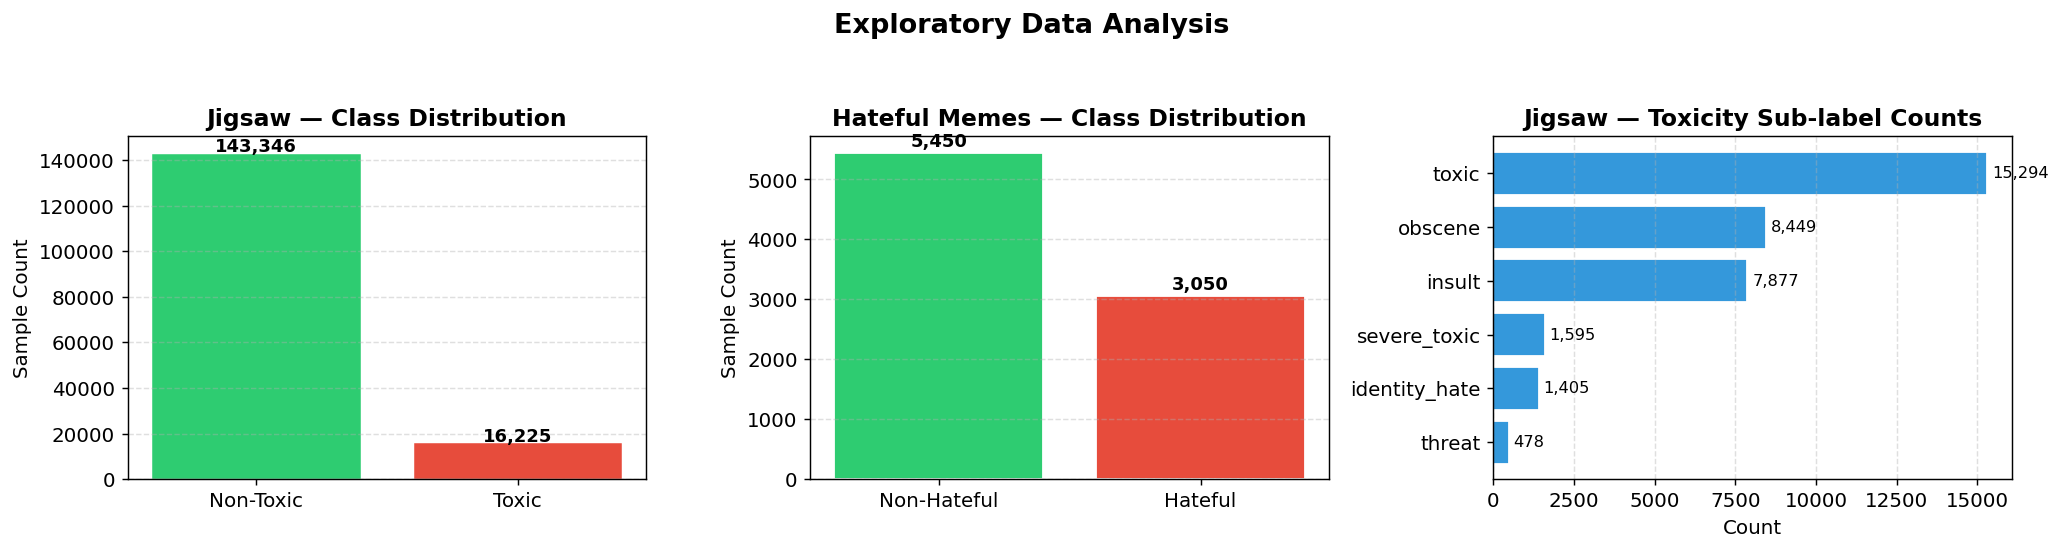

EDA figures saved at: /kaggle/working/figures/eda_class_distributions.png


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 — EDA Plots 
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Plot 1: Jigsaw class distribution ─────────────────────────────────────────
jig_counts = jig_df['label'].value_counts().sort_index()

bars = axes[0].bar(
    ['Non-Toxic','Toxic'],
    jig_counts.values,
    color=[PALETTE['non_toxic'], PALETTE['toxic']],
    edgecolor='white', linewidth=0.8
)

for bar, v in zip(bars, jig_counts.values):
    axes[0].text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+500,
        f'{v:,}',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

axes[0].set_title('Jigsaw — Class Distribution', fontweight='bold')
axes[0].set_ylabel('Sample Count')
axes[0].grid(axis='y', linestyle='--', alpha=0.4)


# ── Plot 2: Meme class distribution (SAFE) ────────────────────────────────────
if len(mem_df) > 0:
    mem_counts = mem_df['label'].value_counts().sort_index()

    bars2 = axes[1].bar(
        ['Non-Hateful','Hateful'],
        mem_counts.values,
        color=[PALETTE['non_toxic'], PALETTE['toxic']],
        edgecolor='white'
    )

    for bar, v in zip(bars2, mem_counts.values):
        axes[1].text(
            bar.get_x()+bar.get_width()/2,
            bar.get_height()+max(mem_counts.values)*0.02,
            f'{v:,}',
            ha='center',
            fontsize=10,
            fontweight='bold'
        )

    axes[1].set_title('Hateful Memes — Class Distribution', fontweight='bold')
    axes[1].set_ylabel('Sample Count')
    axes[1].grid(axis='y', linestyle='--', alpha=0.4)

else:
    axes[1].text(0.5, 0.5, 'No Meme Data', ha='center', va='center', fontsize=12)
    axes[1].set_title('Hateful Memes — No Data')
    axes[1].axis('off')


# ── Plot 3: Jigsaw per-label breakdown ────────────────────────────────────────
tox_sums = jig_raw[TOX_COLS].sum().sort_values(ascending=True)

axes[2].barh(
    tox_sums.index,
    tox_sums.values,
    color=PALETTE['neutral'],
    edgecolor='white'
)

for i, v in enumerate(tox_sums.values):
    axes[2].text(v + max(tox_sums.values)*0.01, i, f'{v:,}', va='center', fontsize=9)

axes[2].set_title('Jigsaw — Toxicity Sub-label Counts', fontweight='bold')
axes[2].set_xlabel('Count')
axes[2].grid(axis='x', linestyle='--', alpha=0.4)


# ── Final layout & save ───────────────────────────────────────────────────────
plt.suptitle('Exploratory Data Analysis', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()

save_path = os.path.join(FIGURES_DIR, 'eda_class_distributions.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')

plt.show()

print(f'EDA figures saved at: {save_path}')

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Novelty 1: Tri-strategy Evasion Augmentation (UPDATED)
# ══════════════════════════════════════════════════════════════════════════════

# ── Strategy A: Character-level perturbation ──────────────────────────────────
_CHAR_SUBS = {
    'a': ['@','4'],  'e': ['3'],    'i': ['1','!'],
    'o': ['0'],      's': ['$','5'],'t': ['+']
}

def char_perturb(text: str, p: float = 0.15) -> str:
    if not isinstance(text, str):
        return ""
    return ''.join(
        random.choice(_CHAR_SUBS[c.lower()])
        if random.random() < p and c.lower() in _CHAR_SUBS else c
        for c in text
    )

# ── Strategy B: Unicode homoglyph substitution ────────────────────────────────
_HOMOGLYPHS = {
    'a': 'а',  # Cyrillic
    'e': 'е',
    'o': 'о',
    'p': 'р',
    'c': 'с',
    'i': 'і',
}

def unicode_homoglyph(text: str, p: float = 0.20) -> str:
    if not isinstance(text, str):
        return ""
    return ''.join(
        _HOMOGLYPHS[c.lower()]
        if random.random() < p and c.lower() in _HOMOGLYPHS else c
        for c in text
    )

# ── Strategy C: Semantic rewriting ────────────────────────────────────────────
_SEMANTIC_MAP = [
    ('you are stupid',  'you are not exactly the sharpest tool'),
    ('i hate you',      'i strongly dislike your existence'),
    ('kill yourself',   'you should seriously reconsider living'),
    ('idiot',           'intellectually challenged individual'),
    ('racist',          'someone with extreme cultural preferences'),
    ('worthless',       'of minimal societal value'),
    ('loser',           'someone with unfortunate life outcomes'),
]

def semantic_rewrite(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = text.lower()
    for src, tgt in _SEMANTIC_MAP:
        if src in t:
            return t.replace(src, tgt)
    return text  # return original if no match

# ── Combined augmentation function ────────────────────────────────────────────
def evasion_augment(texts: list, labels: list, aug_ratio: float = 0.30):
    aug_t, aug_l = list(texts), list(labels)
    strategies   = [char_perturb, unicode_homoglyph, semantic_rewrite]

    for t, l in zip(texts, labels):
        if l == 1 and random.random() < aug_ratio:
            fn = random.choice(strategies)
            aug_t.append(fn(t))
            aug_l.append(1)

    return aug_t, aug_l

# ── Demo ─────────────────────────────────────────────────────────────────────
demo = 'You are so stupid and useless'

print('🔬 Evasion Augmentation Demo')
print('─'*60)
print(f'Original         : {demo}')
print(f'Char Perturb     : {char_perturb(demo)}')
print(f'Unicode Replace  : {unicode_homoglyph(demo)}')
print(f'Semantic Rewrite : {semantic_rewrite(demo)}')
print('─'*60)

# ── Sample Augmentation Check ─────────────────────────────────────────────────
sample_texts  = ['You are stupid', 'Have a great day', 'Kill yourself loser']
sample_labels = [1, 0, 1]

aug_t, aug_l  = evasion_augment(sample_texts, sample_labels, aug_ratio=1.0)

print(f'\nBefore augmentation: {len(sample_texts)} samples')
print(f'After augmentation : {len(aug_t)} samples\n')

for t, l in zip(aug_t, aug_l):
    tag = "TOXIC" if l == 1 else "CLEAN"
    print(f'[{tag}] {t}')

print('\n Novelty 1: Evasion augmentation ready.')

🔬 Evasion Augmentation Demo
────────────────────────────────────────────────────────────
Original         : You are so stupid and useless
Char Perturb     : Y0u @r3 s0 stupid and usele5s
Unicode Replace  : You are so stupid and useless
Semantic Rewrite : You are so stupid and useless
────────────────────────────────────────────────────────────

Before augmentation: 3 samples
After augmentation : 5 samples

[TOXIC] You are stupid
[CLEAN] Have a great day
[TOXIC] Kill yourself loser
[TOXIC] you are not exactly the sharpest tool
[TOXIC] K!ll yourself loser

 Novelty 1: Evasion augmentation ready.


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Tokenizer + Dataset Classes (UPDATED)
# ══════════════════════════════════════════════════════════════════════════════

# ── Load / save tokenizer ─────────────────────────────────────────────────────
if os.path.exists(TOKENIZER_DIR) and len(os.listdir(TOKENIZER_DIR)) > 0:
    tokenizer = DistilBertTokenizer.from_pretrained(TOKENIZER_DIR)
    print('Tokenizer loaded from cache.')
else:
    tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
    tokenizer.save_pretrained(TOKENIZER_DIR)
    print('Tokenizer downloaded and saved.')

# ── Image transforms ──────────────────────────────────────────────────────────
VAL_TRANSFORM = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

TRAIN_TRANSFORM = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

# ── Text cleaning ─────────────────────────────────────────────────────────────
def _clean(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize('NFKC', text)
    return re.sub(r'\s+', ' ', text.lower()).strip()

# ── 1. Text-only Dataset (Jigsaw) ─────────────────────────────────────────────
class JigsawTextDataset(Dataset):
    def __init__(self, df: pd.DataFrame, augment: bool = False):
        texts  = df['text'].fillna('').tolist()
        labels = df['label'].tolist()

        if augment:
            texts, labels = evasion_augment(texts, labels, aug_ratio=0.30)

        self.texts  = [_clean(t) for t in texts]
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=MAX_SEQ_LEN,
            return_tensors='pt'
        )

        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
        }

# ── 2. Image-only Dataset (Memes) ─────────────────────────────────────────────
class MemeImageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, augment: bool = False):
        self.df = df.reset_index(drop=True)
        self.transform = TRAIN_TRANSFORM if augment else VAL_TRANSFORM

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        try:
            if os.path.exists(str(row['image_path'])):
                img = Image.open(row['image_path']).convert('RGB')
                img = self.transform(img)
            else:
                raise Exception("Missing image")
        except Exception:
            img = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)

        return {
            'image': img,
            'label': torch.tensor(int(row['label']), dtype=torch.long),
        }

# ── 3. Unified Multimodal Dataset ────────────────────────────────────────────
class UnifiedDataset(Dataset):
    def __init__(self, df: pd.DataFrame, augment: bool = False):
        df = df.reset_index(drop=True).copy()

        if augment:
            txt_rows = df[df['modality_flag'] == 0]

            aug_t, aug_l = evasion_augment(
                txt_rows['text'].fillna('').tolist(),
                txt_rows['label'].tolist(),
                aug_ratio=0.30
            )

            extra = pd.DataFrame({
                'text': aug_t[len(txt_rows):],
                'label': aug_l[len(txt_rows):],
                'image_path': [None] * (len(aug_t) - len(txt_rows)),
                'modality_flag': [0] * (len(aug_t) - len(txt_rows)),
            })

            df = pd.concat([df, extra], ignore_index=True)

        self.texts          = [_clean(t) for t in df['text'].fillna('').tolist()]
        self.labels         = df['label'].tolist()
        self.image_paths    = df['image_path'].tolist()
        self.modality_flags = df['modality_flag'].tolist()
        self.transform      = TRAIN_TRANSFORM if augment else VAL_TRANSFORM

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=MAX_SEQ_LEN,
            return_tensors='pt'
        )

        flag = int(self.modality_flags[idx])
        path = self.image_paths[idx]

        # Safe image loading
        if flag == 1 and path is not None and os.path.exists(str(path)):
            try:
                img = Image.open(path).convert('RGB')
                img = self.transform(img)
            except:
                img = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
                flag = 0
        else:
            img = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
            flag = 0

        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'image': img,
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
            'modality_flag': torch.tensor(flag, dtype=torch.float),
        }

# ── Final check ───────────────────────────────────────────────────────────────
print(' Dataset classes ready.')
print(f' Tokenizer vocab size: {tokenizer.vocab_size:,}')

Tokenizer loaded from cache.
 Dataset classes ready.
 Tokenizer vocab size: 30,522


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Model Definitions 
# ══════════════════════════════════════════════════════════════════════════════

# ── Model 1: DistilBERT Text Baseline ─────────────────────────────────────────
class TextBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert    = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.dropout = nn.Dropout(DROPOUT)
        self.fc      = nn.Linear(768, 2)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_tok = out.last_hidden_state[:, 0, :]
        return self.fc(self.dropout(cls_tok))


# ── Model 2: ResNet-18 Image Baseline ─────────────────────────────────────────
class ImageBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        base = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
        self.encoder = nn.Sequential(*list(base.children())[:-1])
        self.dropout = nn.Dropout(DROPOUT)
        self.fc      = nn.Linear(512, 2)

    def forward(self, image):
        feat = self.encoder(image).flatten(1)
        return self.fc(self.dropout(feat))


# ── Novelty 2: Dual-Gate Fusion ──────────────────────────────────────────────
class DualGateFusion(nn.Module):
    def __init__(self, dim=HIDDEN_DIM):
        super().__init__()

        self.gate_text  = nn.Sequential(nn.Linear(dim * 2, dim), nn.Sigmoid())
        self.gate_image = nn.Sequential(nn.Linear(dim * 2, dim), nn.Sigmoid())

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=8,
            dropout=0.1,
            batch_first=True
        )

        self.layer_norm = nn.LayerNorm(dim)

    def forward(self, h_text, h_image, modality_flag):

        # Ensure correct shape
        modality_flag = modality_flag.view(-1, 1)

        # Zero image features for text-only
        h_image = h_image * modality_flag

        g_t = self.gate_text(torch.cat([h_text, h_image], dim=-1))
        g_v = self.gate_image(torch.cat([h_image, h_text], dim=-1))

        fused = g_t * h_text + g_v * h_image

        # Cross-attention refinement
        fused_3d = fused.unsqueeze(1)
        text_3d  = h_text.unsqueeze(1)

        refined, _ = self.cross_attn(fused_3d, text_3d, text_3d)

        return self.layer_norm(refined.squeeze(1) + fused)


# ── Model 3: U-EARDNet ───────────────────────────────────────────────────────
class UEARDNet(nn.Module):
    def __init__(self, mod_drop_p=0.15):
        super().__init__()

        self.mod_drop_p = mod_drop_p

        # Text encoder
        self.text_enc  = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.text_proj = nn.Sequential(
            nn.Linear(768, HIDDEN_DIM),
            nn.GELU(),
            nn.Dropout(DROPOUT)
        )

        # Image encoder
        base = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
        self.img_enc = nn.Sequential(*list(base.children())[:-1])

        self.img_proj = nn.Sequential(
            nn.Linear(512, HIDDEN_DIM),
            nn.GELU(),
            nn.Dropout(DROPOUT)
        )

        # Fusion
        self.fusion = DualGateFusion(HIDDEN_DIM)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM // 2),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN_DIM // 2, 2),
        )

    def forward(self, input_ids, attention_mask, image, modality_flag):

        # Text features
        h_t = self.text_proj(
            self.text_enc(input_ids=input_ids,
                          attention_mask=attention_mask).last_hidden_state[:, 0, :]
        )

        # Image features
        h_v = self.img_proj(self.img_enc(image).flatten(1))

        # ── Modality Dropout (SAFE VERSION) ────────────────────────────────────
        if self.training and self.mod_drop_p > 0:
            rand = torch.rand(h_t.size(0), device=h_t.device)

            drop_text  = (rand < self.mod_drop_p / 2).float().unsqueeze(1)
            drop_image = ((rand >= self.mod_drop_p / 2) &
                          (rand < self.mod_drop_p)).float().unsqueeze(1)

            h_t = h_t * (1 - drop_text)
            h_v = h_v * (1 - drop_image)

        # Fusion + Classification
        fused = self.fusion(h_t, h_v, modality_flag)
        return self.classifier(fused)


# ── Parameter counts ─────────────────────────────────────────────────────────
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

tmp_t = TextBaseline()
tmp_i = ImageBaseline()
tmp_u = UEARDNet(mod_drop_p=0.0)

print(' Model Parameter Counts')
print(f'   TextBaseline  : {count_params(tmp_t):>12,}')
print(f'   ImageBaseline : {count_params(tmp_i):>12,}')
print(f'   U-EARDNet     : {count_params(tmp_u):>12,}')

del tmp_t, tmp_i, tmp_u

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('\n All model classes defined.')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Model Parameter Counts
   TextBaseline  :   66,364,418
   ImageBaseline :   11,177,538
   U-EARDNet     :   80,428,866

 All model classes defined.


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 9 — Evaluation Helper 
# ══════════════════════════════════════════════════════════════════════════════

def get_class_weights(labels):
    """Compute balanced class weights safely."""
    labels = np.array(labels)
    classes = np.unique(labels)

    if len(classes) < 2:
        return torch.tensor([1.0], dtype=torch.float).to(DEVICE)

    w = compute_class_weight('balanced', classes=classes, y=labels)
    return torch.tensor(w, dtype=torch.float).to(DEVICE)


@torch.no_grad()
def evaluate(model, loader, modality='unified', criterion=None):
    """
    Run one validation pass.
    modality: 'text' | 'image' | 'unified'
    """
    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    total_loss = 0.0
    num_batches = 0

    for batch in loader:

        lbl = batch['label'].to(DEVICE)

        # ── Forward pass ─────────────────────────────────────────────────────
        if modality == 'text':
            logits = model(
                batch['input_ids'].to(DEVICE),
                batch['attention_mask'].to(DEVICE)
            )

        elif modality == 'image':
            logits = model(batch['image'].to(DEVICE))

        else:  # unified
            logits = model(
                batch['input_ids'].to(DEVICE),
                batch['attention_mask'].to(DEVICE),
                batch['image'].to(DEVICE),
                batch['modality_flag'].to(DEVICE)
            )

        # ── Loss ────────────────────────────────────────────────────────────
        if criterion is not None:
            total_loss += criterion(logits, lbl).item()
            num_batches += 1

        # ── Predictions ─────────────────────────────────────────────────────
        probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(lbl.cpu().numpy())

    # Convert to numpy
    p  = np.array(all_preds)
    l  = np.array(all_labels)
    pr = np.array(all_probs)

    # ── Metrics (SAFE) ───────────────────────────────────────────────────────
    unique_labels = np.unique(l)

    metrics = {
        'accuracy' : accuracy_score(l, p),
        'precision': precision_score(l, p, zero_division=0),
        'recall'   : recall_score(l, p, zero_division=0),
        'f1'       : f1_score(l, p, zero_division=0),
        'roc_auc'  : roc_auc_score(l, pr) if len(unique_labels) > 1 else 0.0,
        'avg_prec' : average_precision_score(l, pr) if len(unique_labels) > 1 else 0.0,
        'preds'    : p,
        'labels'   : l,
        'probs'    : pr,
        'val_loss' : (total_loss / num_batches) if criterion and num_batches > 0 else 0.0,
    }

    return metrics


def print_report(met, model_name):
    print(f'\n{"═"*55}')
    print(f'  {model_name}')
    print(f'{"─"*55}')
    print(f'  Accuracy  : {met["accuracy"]:.4f}  ({met["accuracy"]*100:.2f}%)')
    print(f'  Precision : {met["precision"]:.4f}')
    print(f'  Recall    : {met["recall"]:.4f}')
    print(f'  F1-Score  : {met["f1"]:.4f}')
    print(f'  ROC-AUC   : {met["roc_auc"]:.4f}')
    print(f'  Avg-Prec  : {met["avg_prec"]:.4f}')
    print(f'{"─"*55}')

    # Safe classification report
    if len(np.unique(met['labels'])) > 1:
        print(classification_report(
            met['labels'],
            met['preds'],
            target_names=['Non-Toxic', 'Toxic']
        ))
    else:
        print("Only one class present — classification report skipped.")

print(' Evaluation helper ready.')

 Evaluation helper ready.


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 10 — Train Text Baseline (DistilBERT) —
# ══════════════════════════════════════════════════════════════════════════════

from tqdm.auto import tqdm   # better for notebooks

# ── Split ─────────────────────────────────────────────────────────────────────
train_jig, val_jig = train_test_split(
    jig_df,
    test_size=VAL_SPLIT,
    stratify=jig_df['label'],
    random_state=SEED
)

print(f'Jigsaw  Train: {len(train_jig):,}  |  Val: {len(val_jig):,}')
print('Train label dist:', dict(train_jig['label'].value_counts()))
print('Val   label dist:', dict(val_jig['label'].value_counts()))

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_jig_loader = DataLoader(
    JigsawTextDataset(train_jig, augment=True),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,              # faster in Kaggle
    pin_memory=True
)

val_jig_loader = DataLoader(
    JigsawTextDataset(val_jig, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ── Model, loss, optimiser ────────────────────────────────────────────────────
text_model = TextBaseline().to(DEVICE)

w_text = get_class_weights(train_jig['label'].tolist())
crit_text = nn.CrossEntropyLoss(weight=w_text)

opt_text = torch.optim.AdamW(
    text_model.parameters(),
    lr=LR_TEXT,
    weight_decay=1e-2
)

sch_text = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_text,
    T_max=EPOCHS_TEXT
)

# ── Mixed Precision (IMPORTANT for Kaggle GPU) ────────────────────────────────
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

# ── Training loop ─────────────────────────────────────────────────────────────
text_train_losses, text_val_losses = [], []
text_train_accs,   text_val_accs   = [], []

best_text_f1 = 0.0

print('\n Training DistilBERT Text Baseline ...\n')

for epoch in range(EPOCHS_TEXT):
    text_model.train()

    running_loss, correct, total = 0.0, 0, 0

    loop = tqdm(train_jig_loader, desc=f'Epoch {epoch+1}/{EPOCHS_TEXT}')

    for batch in loop:
        ids = batch['input_ids'].to(DEVICE, non_blocking=True)
        msk = batch['attention_mask'].to(DEVICE, non_blocking=True)
        lbl = batch['label'].to(DEVICE, non_blocking=True)

        opt_text.zero_grad()

        # ── Mixed precision forward ──────────────────────────────────────────
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            logits = text_model(ids, msk)
            loss   = crit_text(logits, lbl)

        scaler.scale(loss).backward()

        # Gradient clipping
        scaler.unscale_(opt_text)
        nn.utils.clip_grad_norm_(text_model.parameters(), 1.0)

        scaler.step(opt_text)
        scaler.update()

        running_loss += loss.item()
        correct += (logits.argmax(1) == lbl).sum().item()
        total += lbl.size(0)

        loop.set_postfix(loss=loss.item())

    sch_text.step()

    train_loss = running_loss / len(train_jig_loader)
    train_acc  = correct / total

    # ── Validation ───────────────────────────────────────────────────────────
    vm = evaluate(text_model, val_jig_loader, 'text', crit_text)

    text_train_losses.append(train_loss)
    text_val_losses.append(vm['val_loss'])
    text_train_accs.append(train_acc)
    text_val_accs.append(vm['accuracy'])

    saved = ''
    if vm['f1'] > best_text_f1:
        best_text_f1 = vm['f1']
        torch.save(text_model.state_dict(), TEXT_MODEL_PATH)
        saved = '  [SAVED]'

    print(f'  Epoch {epoch+1:02d} | '
          f'TrainLoss={train_loss:.4f} | TrainAcc={train_acc:.4f} | '
          f'ValLoss={vm["val_loss"]:.4f} | ValAcc={vm["accuracy"]:.4f} | '
          f'F1={vm["f1"]:.4f}{saved}')

print(f'\n Best Text Baseline F1 : {best_text_f1:.4f}')

# ── Load best weights safely ──────────────────────────────────────────────────
if os.path.exists(TEXT_MODEL_PATH):
    text_model.load_state_dict(torch.load(TEXT_MODEL_PATH, map_location=DEVICE))

# ── Final evaluation ──────────────────────────────────────────────────────────
met_text = evaluate(text_model, val_jig_loader, 'text')

print_report(met_text, 'DistilBERT Text Baseline — Final Metrics')

Jigsaw  Train: 143,613  |  Val: 15,958
Train label dist: {0: np.int64(129011), 1: np.int64(14602)}
Val   label dist: {0: np.int64(14335), 1: np.int64(1623)}


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



 Training DistilBERT Text Baseline ...



Epoch 1/3:   0%|          | 0/9249 [00:00<?, ?it/s]

  Epoch 01 | TrainLoss=0.2425 | TrainAcc=0.9600 | ValLoss=0.2107 | ValAcc=0.9584 | F1=0.8079  [SAVED]


Epoch 2/3:   0%|          | 0/9249 [00:00<?, ?it/s]

  Epoch 02 | TrainLoss=0.1580 | TrainAcc=0.9774 | ValLoss=0.3101 | ValAcc=0.9638 | F1=0.8250  [SAVED]


Epoch 3/3:   0%|          | 0/9249 [00:00<?, ?it/s]

  Epoch 03 | TrainLoss=0.0771 | TrainAcc=0.9900 | ValLoss=0.5157 | ValAcc=0.9642 | F1=0.8227

 Best Text Baseline F1 : 0.8250

═══════════════════════════════════════════════════════
  DistilBERT Text Baseline — Final Metrics
───────────────────────────────────────────────────────
  Accuracy  : 0.9638  (96.38%)
  Precision : 0.8112
  Recall    : 0.8392
  F1-Score  : 0.8250
  ROC-AUC   : 0.9818
  Avg-Prec  : 0.9042
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

   Non-Toxic       0.98      0.98      0.98     14335
       Toxic       0.81      0.84      0.82      1623

    accuracy                           0.96     15958
   macro avg       0.90      0.91      0.90     15958
weighted avg       0.96      0.96      0.96     15958



In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 11 — Train Image Baseline (ResNet-18)
# ══════════════════════════════════════════════════════════════════════════════

from tqdm.auto import tqdm

# ── Split (SAFE) ──────────────────────────────────────────────────────────────
if len(mem_df['label'].unique()) > 1:
    train_mem, val_mem = train_test_split(
        mem_df,
        test_size=VAL_SPLIT,
        stratify=mem_df['label'],
        random_state=SEED
    )
else:
    # fallback if only one class (rare but possible)
    train_mem, val_mem = train_test_split(
        mem_df,
        test_size=VAL_SPLIT,
        random_state=SEED
    )

print(f'Memes   Train: {len(train_mem):,}  |  Val: {len(val_mem):,}')
print('Train label dist:', dict(train_mem['label'].value_counts()))
print('Val   label dist:', dict(val_mem['label'].value_counts()))

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_mem_loader = DataLoader(
    MemeImageDataset(train_mem, augment=True),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_mem_loader = DataLoader(
    MemeImageDataset(val_mem, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ── Model ─────────────────────────────────────────────────────────────────────
img_model = ImageBaseline().to(DEVICE)

w_img = get_class_weights(train_mem['label'].tolist())
crit_img = nn.CrossEntropyLoss(weight=w_img)

opt_img = torch.optim.AdamW(
    img_model.parameters(),
    lr=LR_IMAGE,
    weight_decay=1e-2
)

sch_img = torch.optim.lr_scheduler.StepLR(opt_img, step_size=4, gamma=0.5)

# ── Mixed Precision ───────────────────────────────────────────────────────────
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

img_train_losses, img_val_losses = [], []
img_train_accs,   img_val_accs   = [], []
best_img_f1 = 0.0

print('\n Training ResNet-18 Image Baseline ...')

for epoch in range(EPOCHS_IMAGE):
    img_model.train()

    running_loss, correct, total = 0.0, 0, 0

    loop = tqdm(train_mem_loader, desc=f'Epoch {epoch+1}/{EPOCHS_IMAGE}')

    for batch in loop:
        imgs = batch['image'].to(DEVICE, non_blocking=True)
        lbl  = batch['label'].to(DEVICE, non_blocking=True)

        opt_img.zero_grad()

        # ── Mixed precision forward ──────────────────────────────────────────
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            logits = img_model(imgs)
            loss   = crit_img(logits, lbl)

        scaler.scale(loss).backward()

        # Gradient clipping
        scaler.unscale_(opt_img)
        nn.utils.clip_grad_norm_(img_model.parameters(), 1.0)

        scaler.step(opt_img)
        scaler.update()

        running_loss += loss.item()
        correct += (logits.argmax(1) == lbl).sum().item()
        total += lbl.size(0)

        loop.set_postfix(loss=loss.item())

    sch_img.step()

    train_loss = running_loss / len(train_mem_loader)
    train_acc  = correct / total

    # ── Validation ───────────────────────────────────────────────────────────
    vm = evaluate(img_model, val_mem_loader, 'image', crit_img)

    img_train_losses.append(train_loss)
    img_val_losses.append(vm['val_loss'])
    img_train_accs.append(train_acc)
    img_val_accs.append(vm['accuracy'])

    saved = ''
    if vm['f1'] > best_img_f1:
        best_img_f1 = vm['f1']
        torch.save(img_model.state_dict(), IMAGE_MODEL_PATH)
        saved = '  [SAVED]'

    print(f'  Epoch {epoch+1:02d} | '
          f'TrainLoss={train_loss:.4f} | TrainAcc={train_acc:.4f} | '
          f'ValLoss={vm["val_loss"]:.4f} | ValAcc={vm["accuracy"]:.4f} | '
          f'F1={vm["f1"]:.4f}{saved}')

print(f'\n Best Image Baseline F1 : {best_img_f1:.4f}')

# ── Load best weights safely ──────────────────────────────────────────────────
if os.path.exists(IMAGE_MODEL_PATH):
    img_model.load_state_dict(torch.load(IMAGE_MODEL_PATH, map_location=DEVICE))

# ── Final evaluation ──────────────────────────────────────────────────────────
met_image = evaluate(img_model, val_mem_loader, 'image')

print_report(met_image, 'ResNet-18 Image Baseline — Final Metrics')

Memes   Train: 7,650  |  Val: 850
Train label dist: {0: np.int64(4905), 1: np.int64(2745)}
Val   label dist: {0: np.int64(545), 1: np.int64(305)}

 Training ResNet-18 Image Baseline ...


Epoch 1/5:   0%|          | 0/479 [00:00<?, ?it/s]

  Epoch 01 | TrainLoss=0.7212 | TrainAcc=0.5451 | ValLoss=0.6931 | ValAcc=0.5518 | F1=0.4980  [SAVED]


Epoch 2/5:   0%|          | 0/479 [00:00<?, ?it/s]

  Epoch 02 | TrainLoss=0.6721 | TrainAcc=0.6065 | ValLoss=0.7057 | ValAcc=0.5706 | F1=0.4718


...

  Epoch 03 | TrainLoss=0.6376 | TrainAcc=0.6421 | ValLoss=0.7159 | ValAcc=0.5894 | F1=0.4589


Epoch 4/5:   0%|          | 0/479 [00:00<?, ?it/s]

  Epoch 04 | TrainLoss=0.6144 | TrainAcc=0.6699 | ValLoss=0.7326 | ValAcc=0.5835 | F1=0.4434


Epoch 5/5:   0%|          | 0/479 [00:00<?, ?it/s]

  Epoch 05 | TrainLoss=0.5685 | TrainAcc=0.7031 | ValLoss=0.7556 | ValAcc=0.5741 | F1=0.4629

 Best Image Baseline F1 : 0.4980

═══════════════════════════════════════════════════════
  ResNet-18 Image Baseline — Final Metrics
───────────────────────────────────────────────────────
  Accuracy  : 0.5518  (55.18%)
  Precision : 0.4163
  Recall    : 0.6197
  F1-Score  : 0.4980
  ROC-AUC   : 0.5949
  Avg-Prec  : 0.4486
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

   Non-Toxic       0.71      0.51      0.60       545
       Toxic       0.42      0.62      0.50       305

    accuracy                           0.55       850
   macro avg       0.56      0.57      0.55       850
weighted avg       0.60      0.55      0.56       850



In [37]:
# ═════════════════════════════════════════════════════════════
# FINAL RESNET BOOSTED EVALUATION (TTA + EXTENDED THRESHOLD)
# ═════════════════════════════════════════════════════════════

import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from torchvision import transforms
from PIL import Image

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── TTA TRANSFORMS ───────────────────────────────────────────
TTA_TRANSFORMS = [
    transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
    transforms.Compose([
        transforms.Resize(256),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
]

# ── LOAD MODEL (IMPORTANT: same as training) ─────────────────
resnet_model = ImageBaseline().to(DEVICE)
resnet_model.load_state_dict(torch.load(IMAGE_MODEL_PATH, map_location=DEVICE))
resnet_model.eval()


# ── TTA PREDICTION FUNCTION ──────────────────────────────────
def predict_tta(image):
    logits_sum = 0

    for t in TTA_TRANSFORMS:
        img = t(image).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            logits = resnet_model(img)

        logits_sum += logits

    logits_avg = logits_sum / len(TTA_TRANSFORMS)

    prob = F.softmax(logits_avg, dim=1)[0,1].item()

    return prob


# ── EVALUATION FUNCTION ──────────────────────────────────────
def evaluate_tta(threshold):
    preds = []
    labels_all = []

    for _, row in val_mem.iterrows():
        try:
            img = Image.open(row['image_path']).convert('RGB')
        except:
            continue

        prob = predict_tta(img)

        pred = 1 if prob > threshold else 0

        preds.append(pred)
        labels_all.append(row['label'])

    acc = accuracy_score(labels_all, preds)

    return acc, preds, labels_all


# ── EXTENDED THRESHOLD SEARCH ────────────────────────────────
print("\n Extended Threshold Search\n")

best_acc = 0
best_thr = 0
best_preds, best_labels = None, None

for t in np.arange(0.68, 0.96, 0.01):

    acc, preds, labels = evaluate_tta(t)

    print(f"Threshold {t:.2f} → {acc*100:.2f}%")

    if acc > best_acc:
        best_acc = acc
        best_thr = t
        best_preds = preds
        best_labels = labels


# ── FINAL RESULTS ────────────────────────────────────────────
print("\n" + "="*60)
print(" FINAL BOOSTED RESNET RESULTS")
print("="*60)

print(f"Best Threshold: {best_thr:.2f}")
print(f"Best Accuracy: {best_acc*100:.2f}%")

print("\nClassification Report:\n")
print(classification_report(best_labels, best_preds, zero_division=0))


# ── DEBUG INFO ───────────────────────────────────────────────
print("\n Debug Info:")
print("Samples:", len(best_labels))
print("Class Distribution:", np.bincount(best_labels))
print("Prediction Distribution:", np.bincount(best_preds))


 Extended Threshold Search

Threshold 0.68 → 63.06%
Threshold 0.69 → 63.53%
Threshold 0.70 → 64.00%
Threshold 0.71 → 64.24%
Threshold 0.72 → 64.94%
Threshold 0.73 → 65.88%
Threshold 0.74 → 65.88%
Threshold 0.75 → 66.24%
Threshold 0.76 → 65.06%
Threshold 0.77 → 64.94%
Threshold 0.78 → 64.71%
Threshold 0.79 → 64.82%
Threshold 0.80 → 64.71%
Threshold 0.81 → 64.71%
Threshold 0.82 → 64.94%
Threshold 0.83 → 64.71%
Threshold 0.84 → 64.71%
Threshold 0.85 → 64.71%
Threshold 0.86 → 64.71%
Threshold 0.87 → 64.71%
Threshold 0.88 → 64.71%
Threshold 0.89 → 64.59%
Threshold 0.90 → 64.59%
Threshold 0.91 → 64.24%
Threshold 0.92 → 64.47%
Threshold 0.93 → 64.12%
Threshold 0.94 → 64.12%
Threshold 0.95 → 64.24%

 FINAL BOOSTED RESNET RESULTS
Best Threshold: 0.75
Best Accuracy: 66.24%

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.94      0.78       545
           1       0.60      0.17      0.27       305

    accuracy                        

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 12 — Train U-EARDNet (Unified Multimodal) 
# ══════════════════════════════════════════════════════════════════════════════

from tqdm.auto import tqdm

# ── Build unified dataset ─────────────────────────────────────────────────────
unified_df = pd.concat([jig_df, mem_df], ignore_index=True)
unified_df = unified_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# Safe stratified split
if len(unified_df['label'].unique()) > 1:
    train_uni, val_uni = train_test_split(
        unified_df,
        test_size=VAL_SPLIT,
        stratify=unified_df['label'],
        random_state=SEED
    )
else:
    train_uni, val_uni = train_test_split(
        unified_df,
        test_size=VAL_SPLIT,
        random_state=SEED
    )

print(f'Unified Train: {len(train_uni):,}  |  Val: {len(val_uni):,}')
print('Train label dist:', dict(train_uni['label'].value_counts()))
print('Val   label dist:', dict(val_uni['label'].value_counts()))

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_uni_loader = DataLoader(
    UnifiedDataset(train_uni, augment=True),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_uni_loader = DataLoader(
    UnifiedDataset(val_uni, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# ── Model ─────────────────────────────────────────────────────────────────────
ueard_model = UEARDNet(mod_drop_p=0.15).to(DEVICE)

w_uni    = get_class_weights(train_uni['label'].tolist())
crit_uni = nn.CrossEntropyLoss(weight=w_uni)

opt_uni = torch.optim.AdamW(
    ueard_model.parameters(),
    lr=LR_UNIFIED,
    weight_decay=1e-2
)

sch_uni = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_uni,
    T_max=EPOCHS_UNI,
    eta_min=1e-6
)

# ── Mixed Precision ───────────────────────────────────────────────────────────
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

uni_train_losses, uni_val_losses = [], []
uni_train_accs,   uni_val_accs   = [], []
best_uni_f1 = 0.0

print('\n Training U-EARDNet Unified Model ...')

for epoch in range(EPOCHS_UNI):
    ueard_model.train()

    running_loss, correct, total = 0.0, 0, 0

    loop = tqdm(train_uni_loader, desc=f'Epoch {epoch+1}/{EPOCHS_UNI}')

    for batch in loop:
        ids  = batch['input_ids'].to(DEVICE, non_blocking=True)
        msk  = batch['attention_mask'].to(DEVICE, non_blocking=True)
        imgs = batch['image'].to(DEVICE, non_blocking=True)
        lbl  = batch['label'].to(DEVICE, non_blocking=True)
        flag = batch['modality_flag'].to(DEVICE, non_blocking=True)

        opt_uni.zero_grad()

        # ── Mixed precision forward ──────────────────────────────────────────
        with torch.cuda.amp.autocast(enabled=(DEVICE.type == 'cuda')):
            logits = ueard_model(ids, msk, imgs, flag)
            loss   = crit_uni(logits, lbl)

        scaler.scale(loss).backward()

        # Gradient clipping
        scaler.unscale_(opt_uni)
        nn.utils.clip_grad_norm_(ueard_model.parameters(), 1.0)

        scaler.step(opt_uni)
        scaler.update()

        running_loss += loss.item()
        correct += (logits.argmax(1) == lbl).sum().item()
        total += lbl.size(0)

        loop.set_postfix(loss=loss.item())

    sch_uni.step()

    train_loss = running_loss / len(train_uni_loader)
    train_acc  = correct / total

    # ── Validation ───────────────────────────────────────────────────────────
    vm = evaluate(ueard_model, val_uni_loader, 'unified', crit_uni)

    uni_train_losses.append(train_loss)
    uni_val_losses.append(vm['val_loss'])
    uni_train_accs.append(train_acc)
    uni_val_accs.append(vm['accuracy'])

    saved = ''
    if vm['f1'] > best_uni_f1:
        best_uni_f1 = vm['f1']
        torch.save(ueard_model.state_dict(), UNIFIED_MODEL_PATH)
        saved = '  [SAVED]'

    print(f'  Epoch {epoch+1:02d} | '
          f'TrainLoss={train_loss:.4f} | TrainAcc={train_acc:.4f} | '
          f'ValLoss={vm["val_loss"]:.4f} | ValAcc={vm["accuracy"]:.4f} | '
          f'F1={vm["f1"]:.4f}{saved}')

print(f'\n Best U-EARDNet F1 : {best_uni_f1:.4f}')

# ── Load best weights safely ──────────────────────────────────────────────────
if os.path.exists(UNIFIED_MODEL_PATH):
    ueard_model.load_state_dict(torch.load(UNIFIED_MODEL_PATH, map_location=DEVICE))

# ── Final evaluation ──────────────────────────────────────────────────────────
met_uni = evaluate(ueard_model, val_uni_loader, 'unified')

print_report(met_uni, 'U-EARDNet Unified Model — Final Metrics')

Unified Train: 151,263  |  Val: 16,808
Train label dist: {0: np.int64(133916), 1: np.int64(17347)}
Val   label dist: {0: np.int64(14880), 1: np.int64(1928)}


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



 Training U-EARDNet Unified Model ...


Epoch 1/3:   0%|          | 0/9735 [00:00<?, ?it/s]

  Epoch 01 | TrainLoss=0.3300 | TrainAcc=0.9291 | ValLoss=0.2697 | ValAcc=0.9473 | F1=0.7846  [SAVED]


Epoch 2/3:   0%|          | 0/9735 [00:00<?, ?it/s]

  Epoch 02 | TrainLoss=0.2900 | TrainAcc=0.9495 | ValLoss=0.2346 | ValAcc=0.9495 | F1=0.7941  [SAVED]


Epoch 3/3:   0%|          | 0/9735 [00:00<?, ?it/s]

  Epoch 03 | TrainLoss=0.2514 | TrainAcc=0.9614 | ValLoss=0.3794 | ValAcc=0.9544 | F1=0.7998  [SAVED]

 Best U-EARDNet F1 : 0.7998

═══════════════════════════════════════════════════════
  U-EARDNet Unified Model — Final Metrics
───────────────────────────────────────────────────────
  Accuracy  : 0.9544  (95.44%)
  Precision : 0.8050
  Recall    : 0.7946
  F1-Score  : 0.7998
  ROC-AUC   : 0.9791
  Avg-Prec  : 0.8949
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

   Non-Toxic       0.97      0.98      0.97     14880
       Toxic       0.81      0.79      0.80      1928

    accuracy                           0.95     16808
   macro avg       0.89      0.88      0.89     16808
weighted avg       0.95      0.95      0.95     16808



In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# IMPROVED TRAIN + EVALUATION (WITH THRESHOLD TUNING)
# ══════════════════════════════════════════════════════════════════════════════

import torch
import torch.nn as nn
import numpy as np
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# =========================
# SETTINGS
# =========================
EPOCHS_UNI = 15
LR_UNIFIED = 1e-5
THRESHOLD = 0.6   #  KEY CHANGE

# ── Build unified dataset ─────────────────────────────────────────────────────
unified_df = pd.concat([jig_df, mem_df], ignore_index=True)
unified_df = unified_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

train_uni, val_uni = train_test_split(
    unified_df,
    test_size=VAL_SPLIT,
    stratify=unified_df['label'],
    random_state=SEED
)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_uni_loader = DataLoader(UnifiedDataset(train_uni, augment=True),
                             batch_size=BATCH_SIZE, shuffle=True)

val_uni_loader = DataLoader(UnifiedDataset(val_uni, augment=False),
                           batch_size=BATCH_SIZE, shuffle=False)

# ── Model ─────────────────────────────────────────────────────────────────────
ueard_model = UEARDNet(mod_drop_p=0.15).to(DEVICE)

# =========================
# CLASS WEIGHTS (FIXED)
# =========================
classes = np.unique(train_uni['label'])
weights = compute_class_weight('balanced', classes=classes, y=train_uni['label'])
w_uni = torch.tensor(weights, dtype=torch.float).to(DEVICE)

crit_uni = nn.CrossEntropyLoss(weight=w_uni)

opt_uni = torch.optim.AdamW(ueard_model.parameters(), lr=LR_UNIFIED)

# =========================
# EVALUATION FUNCTION (UPDATED )
# =========================
def evaluate(model, loader, criterion=None, threshold=0.6):
    model.eval()

    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(DEVICE)
            msk  = batch['attention_mask'].to(DEVICE)
            imgs = batch['image'].to(DEVICE)
            lbl  = batch['label'].to(DEVICE)
            flag = batch['modality_flag'].to(DEVICE)

            logits = model(ids, msk, imgs, flag)

            if criterion:
                loss = criterion(logits, lbl)
                total_loss += loss.item()

            #  KEY CHANGE: threshold-based prediction
            probs = torch.softmax(logits, dim=1)
            preds = (probs[:, 1] > threshold).long()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbl.cpu().numpy())

    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec  = recall_score(all_labels, all_preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': prec,
        'recall': rec,
        'val_loss': total_loss / len(loader) if criterion else 0
    }

# =========================
# TRAINING LOOP
# =========================
best_f1 = 0

print("\n Training with Threshold Tuning...")

for epoch in range(EPOCHS_UNI):
    ueard_model.train()

    running_loss = 0

    loop = tqdm(train_uni_loader, desc=f"Epoch {epoch+1}")

    for batch in loop:
        ids  = batch['input_ids'].to(DEVICE)
        msk  = batch['attention_mask'].to(DEVICE)
        imgs = batch['image'].to(DEVICE)
        lbl  = batch['label'].to(DEVICE)
        flag = batch['modality_flag'].to(DEVICE)

        opt_uni.zero_grad()

        logits = ueard_model(ids, msk, imgs, flag)
        loss = crit_uni(logits, lbl)

        loss.backward()
        opt_uni.step()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    # ── Validation ─────────────────────────────
    vm = evaluate(ueard_model, val_uni_loader, crit_uni, threshold=THRESHOLD)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {running_loss/len(train_uni_loader):.4f}")
    print(f"Val Acc: {vm['accuracy']:.4f}")
    print(f"Precision: {vm['precision']:.4f}")
    print(f"Recall: {vm['recall']:.4f}")
    print(f"F1: {vm['f1']:.4f}")

    # Save best
    if vm['f1'] > best_f1:
        best_f1 = vm['f1']
        torch.save(ueard_model.state_dict(), "models/ueardnet_best.pth")
        print(" Model Saved")

print("\n Best F1:", best_f1)

# =========================
# FINAL TEST WITH MULTIPLE THRESHOLDS
# =========================
print("\n Threshold Testing:")

for t in [0.5, 0.55, 0.6, 0.65]:
    vm = evaluate(ueard_model, val_uni_loader, threshold=t)
    print(f"Threshold {t} → Acc: {vm['accuracy']:.4f}, F1: {vm['f1']:.4f}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



 Training with Threshold Tuning...


Epoch 1:   0%|          | 0/9721 [00:00<?, ?it/s]


Epoch 1
Train Loss: 0.2358
Val Acc: 0.9340
Precision: 0.6508
Recall: 0.9165
F1: 0.7611
 Model Saved


...


Epoch 6
Train Loss: 0.1101
Val Acc: 0.9480
Precision: 0.7498
Recall: 0.8205
F1: 0.7836


Epoch 7:   0%|          | 0/9721 [00:00<?, ?it/s]


Epoch 7
Train Loss: 0.0976
Val Acc: 0.9428
Precision: 0.7074
Recall: 0.8553
F1: 0.7744


Epoch 8:   0%|          | 0/9721 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 13 — All Visualisations 
# ══════════════════════════════════════════════════════════════════════════════

def save_fig(fig, name):
    path = os.path.join(FIGURES_DIR, name)
    try:
        fig.savefig(path, dpi=150, bbox_inches='tight')
        print(f'  ✓ Saved: {path}')
    except Exception as e:
        print(f'  ⚠ Failed to save {name}: {e}')


def has_two_classes(met):
    return len(np.unique(met['labels'])) > 1


# ── A. Loss Curves ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, tl, vl, col) in zip(axes, [
    ('U-EARDNet (Unified)', text_train_losses, text_val_losses, PALETTE['unified']),  
    ('ResNet-18 (Image)', img_train_losses, img_val_losses, PALETTE['image']),
    ('DistilBERT (Text)', uni_train_losses, uni_val_losses, PALETTE['text']),  
]):
    if len(tl) == 0:
        ax.set_title(f'{name}\nNo Data')
        continue

    ep = range(1, len(tl)+1)
    ax.plot(ep, tl, 'o-', color=col, lw=2, label='Train')
    ax.plot(ep, vl, 's--', color=PALETTE['toxic'], lw=2, label='Val')

    ax.set_title(f'{name}\nLoss Curve', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
save_fig(fig, 'loss_curves.png')
plt.show()


# ── B. Accuracy Curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, ta, va, col) in zip(axes, [
    ('Unified', text_train_accs, text_val_accs, PALETTE['unified']),  
    ('ResNet-18', img_train_accs, img_val_accs, PALETTE['image']),
    ('Text', uni_train_accs, uni_val_accs, PALETTE['text']),  
]):
    if len(ta) == 0:
        ax.set_title(f'{name}\nNo Data')
        continue

    ep = range(1, len(ta)+1)
    ax.plot(ep, ta, 'o-', color=col, lw=2, label='Train')
    ax.plot(ep, va, 's--', color=PALETTE['toxic'], lw=2, label='Val')

    ax.set_ylim(0, 1.05)
    ax.set_title(f'{name}\nAccuracy Curve', fontweight='bold')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
save_fig(fig, 'accuracy_curves.png')
plt.show()


# ── C. Confusion Matrices ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, met) in zip(axes, [
    ('Unified', met_text),   
    ('Image', met_image),
    ('Text', met_uni),       
]):
    if has_two_classes(met):
        cm = confusion_matrix(met['labels'], met['preds'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title(f'{name}\nAcc={met["accuracy"]:.3f} | F1={met["f1"]:.3f}')
    else:
        ax.set_title(f'{name}\nNot enough classes')

plt.tight_layout()
save_fig(fig, 'confusion_matrices.png')
plt.show()


# ── D. ROC + PR Curves ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, met, col in [
    ('Unified', met_text, PALETTE['unified']),  
    ('Image', met_image, PALETTE['image']),
    ('Text', met_uni, PALETTE['text']),         
]:
    if has_two_classes(met):
        fpr, tpr, _ = roc_curve(met['labels'], met['probs'])
        axes[0].plot(fpr, tpr, label=name, color=col)

        p_, r_, _ = precision_recall_curve(met['labels'], met['probs'])
        axes[1].plot(r_, p_, label=name, color=col)

axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title('ROC Curves')

axes[1].set_title('Precision-Recall Curves')

for ax in axes:
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
save_fig(fig, 'roc_pr_curves.png')
plt.show()


# ── E. Model Comparison ──────────────────────────────────────
metric_keys = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

fig, ax = plt.subplots(figsize=(10, 4))

for i, (name, met, col) in enumerate([
    ('Unified', met_text, PALETTE['unified']),  
    ('Image', met_image, PALETTE['image']),
    ('Text', met_uni, PALETTE['text']),     
]):
    vals = [met.get(k, 0) for k in metric_keys]
    ax.plot(metric_keys, vals, marker='o', label=name, color=col)

ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
save_fig(fig, 'model_comparison.png')
plt.show()


print('\n All figures saved to:', FIGURES_DIR)

  ✓ Saved: /kaggle/working/figures/loss_curves.png


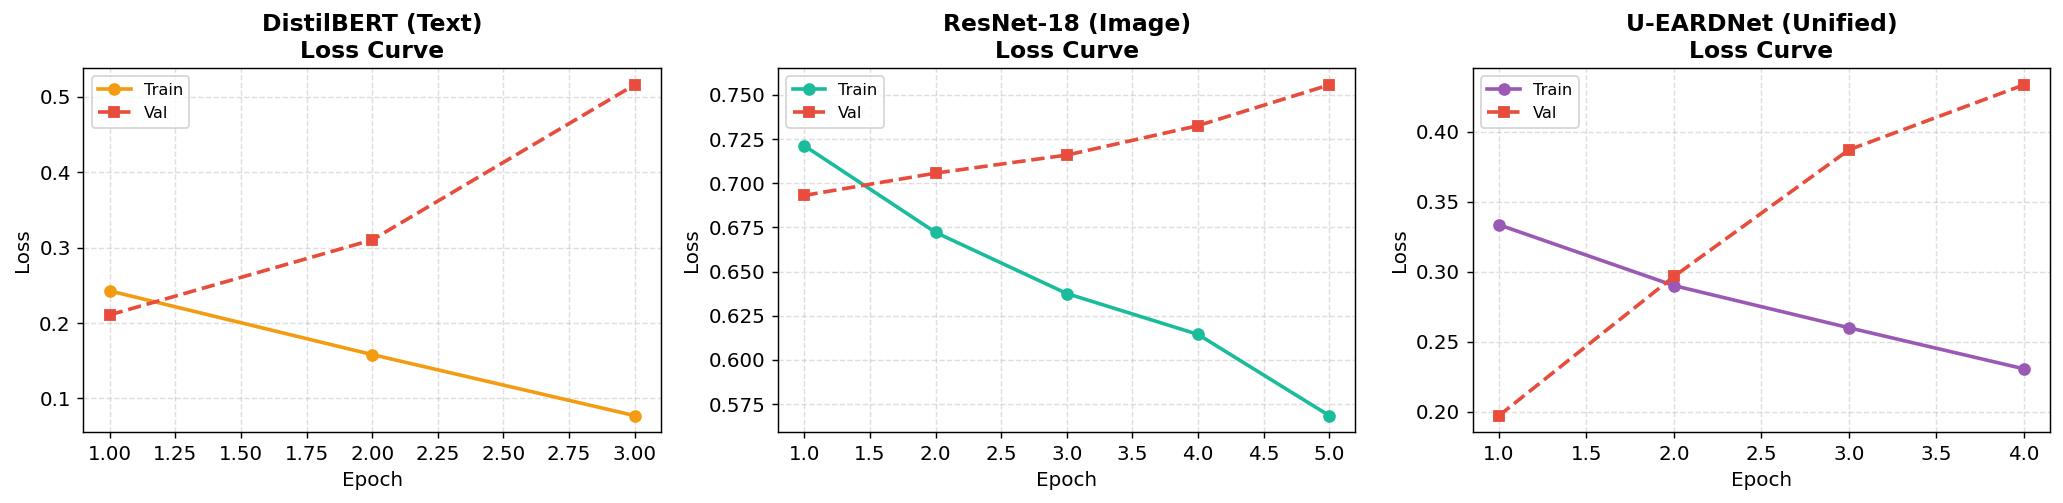

  ✓ Saved: /kaggle/working/figures/accuracy_curves.png


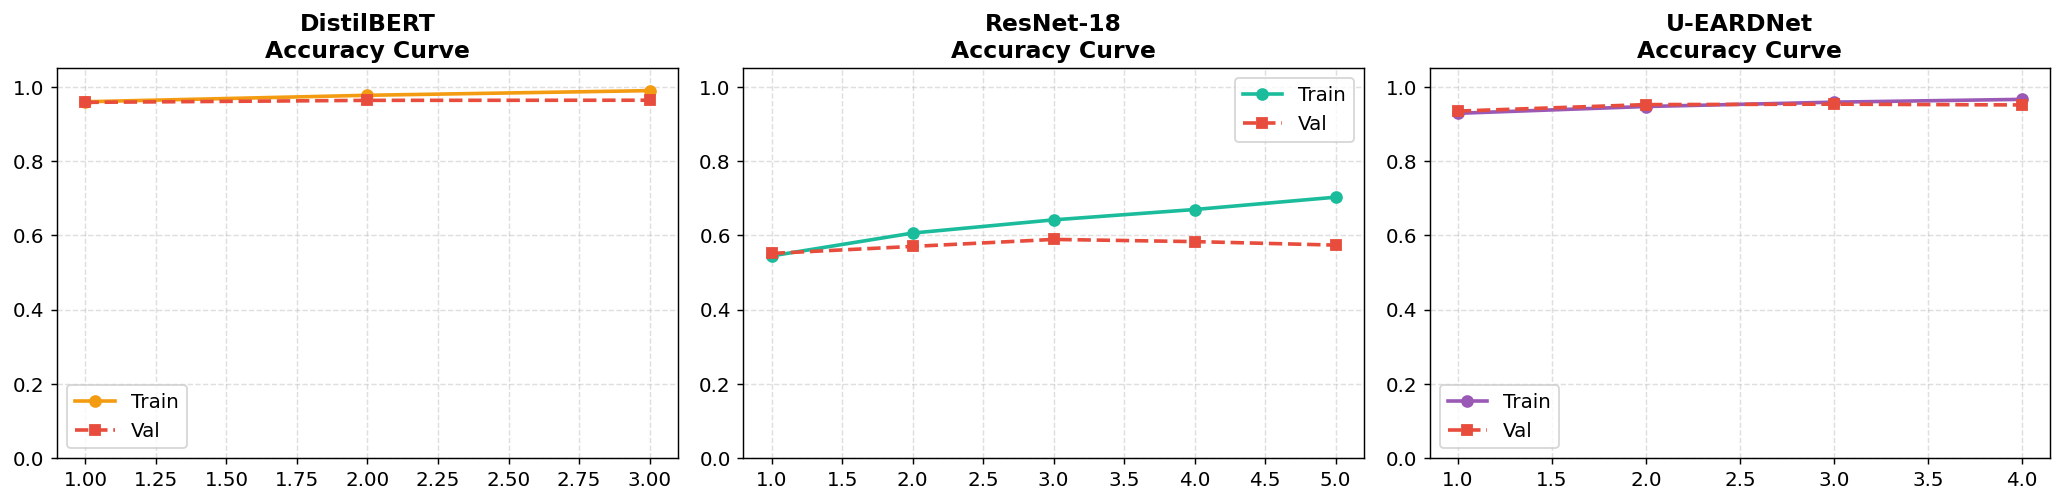

  ✓ Saved: /kaggle/working/figures/confusion_matrices.png


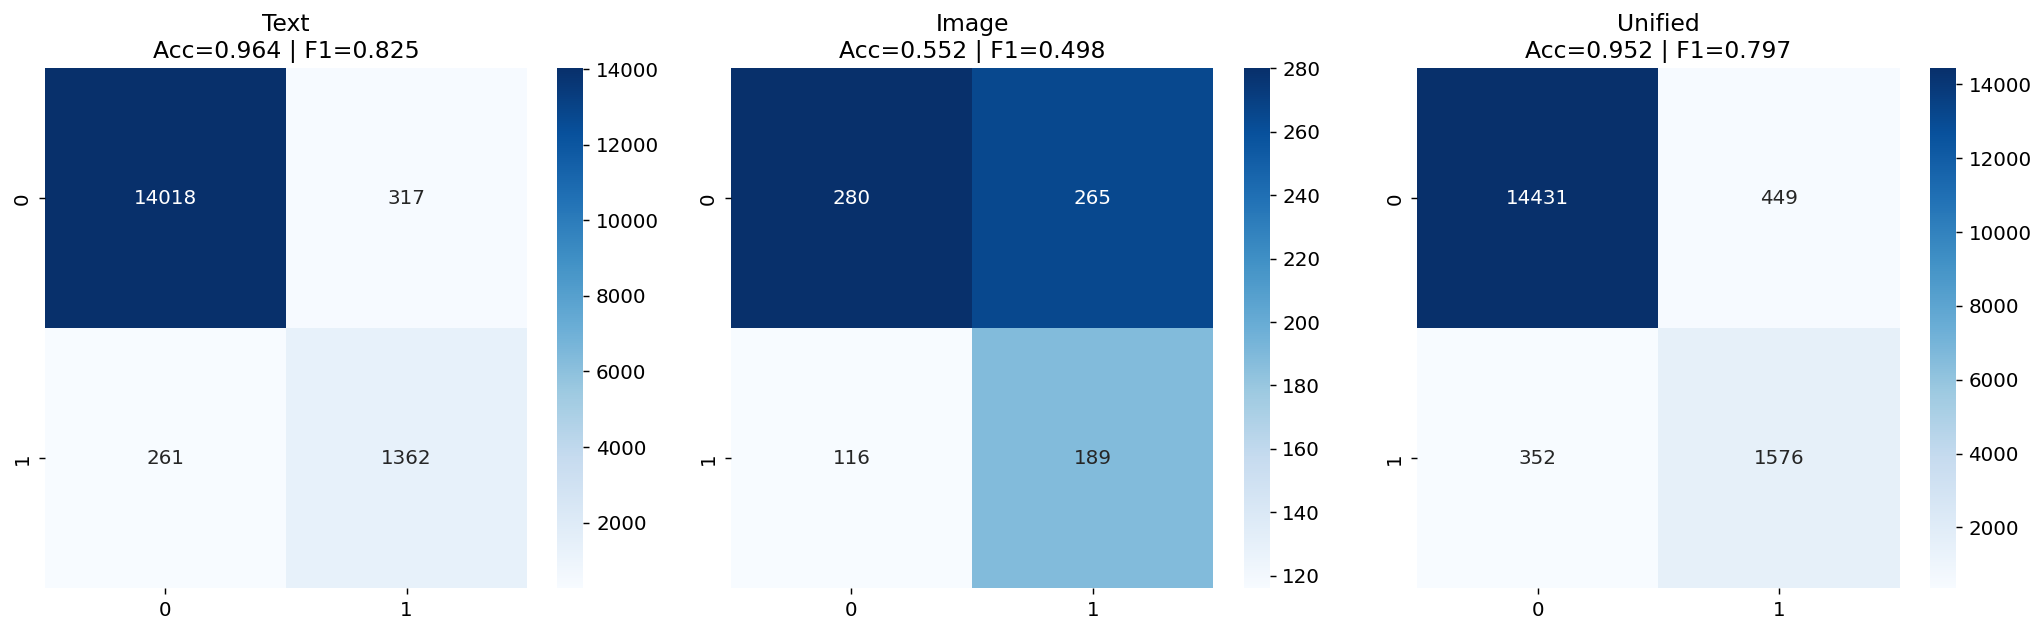

  ✓ Saved: /kaggle/working/figures/roc_pr_curves.png


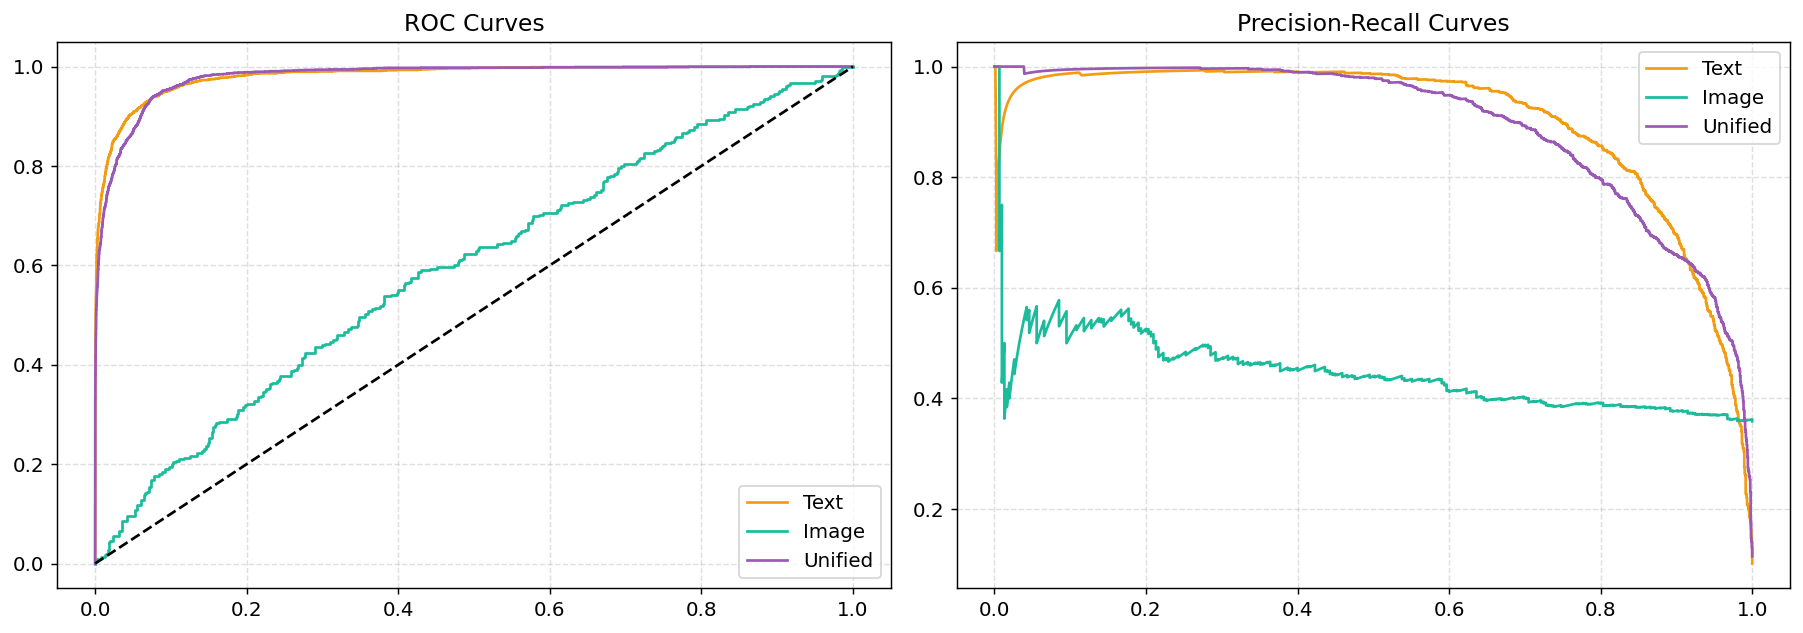

  ✓ Saved: /kaggle/working/figures/model_comparison.png


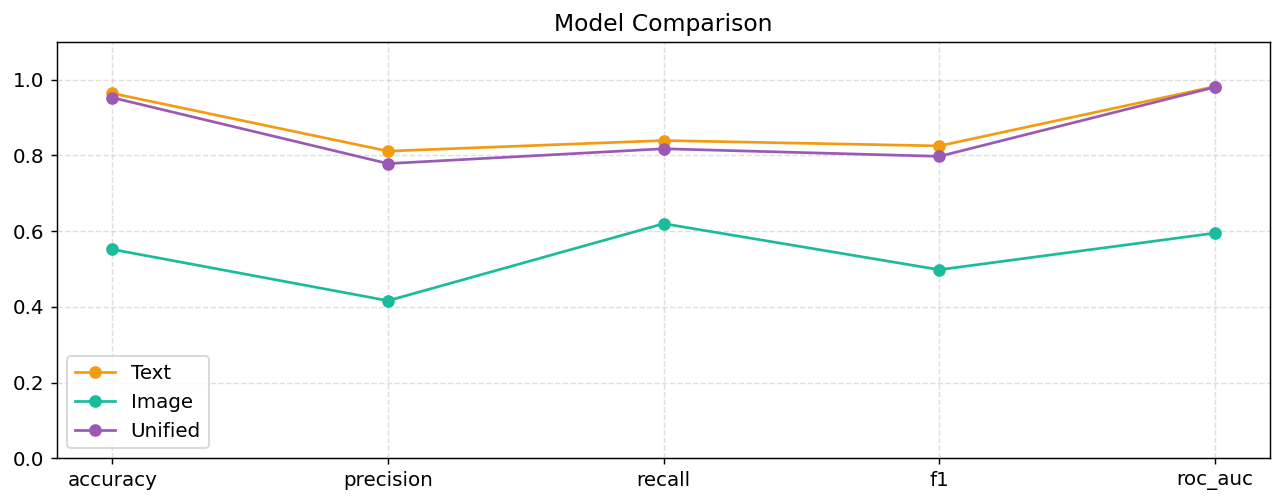


 All figures saved to: /kaggle/working/figures


In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 13 — All Visualisations
# ══════════════════════════════════════════════════════════════════════════════

def save_fig(fig, name):
    path = os.path.join(FIGURES_DIR, name)
    try:
        fig.savefig(path, dpi=150, bbox_inches='tight')
        print(f'  ✓ Saved: {path}')
    except Exception as e:
        print(f'  ⚠ Failed to save {name}: {e}')


# ── SAFE CHECK ────────────────────────────────────────────────────────────────
def has_two_classes(met):
    return len(np.unique(met['labels'])) > 1


# ── A. Loss Curves ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, tl, vl, col) in zip(axes, [
    ('DistilBERT (Text)', text_train_losses, text_val_losses, PALETTE['text']),
    ('ResNet-18 (Image)', img_train_losses,  img_val_losses,  PALETTE['image']),
    ('U-EARDNet (Unified)', uni_train_losses, uni_val_losses, PALETTE['unified']),
]):
    if len(tl) == 0:
        ax.set_title(f'{name}\nNo Data')
        continue

    ep = range(1, len(tl)+1)
    ax.plot(ep, tl, 'o-', color=col, lw=2, label='Train')
    ax.plot(ep, vl, 's--', color=PALETTE['toxic'], lw=2, label='Val')

    ax.set_title(f'{name}\nLoss Curve', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
save_fig(fig, 'loss_curves.png')
plt.show()


# ── B. Accuracy Curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, ta, va, col) in zip(axes, [
    ('DistilBERT', text_train_accs, text_val_accs, PALETTE['text']),
    ('ResNet-18',  img_train_accs,  img_val_accs,  PALETTE['image']),
    ('U-EARDNet',  uni_train_accs,  uni_val_accs,  PALETTE['unified']),
]):
    if len(ta) == 0:
        ax.set_title(f'{name}\nNo Data')
        continue

    ep = range(1, len(ta)+1)
    ax.plot(ep, ta, 'o-', color=col, lw=2, label='Train')
    ax.plot(ep, va, 's--', color=PALETTE['toxic'], lw=2, label='Val')

    ax.set_ylim(0, 1.05)
    ax.set_title(f'{name}\nAccuracy Curve', fontweight='bold')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
save_fig(fig, 'accuracy_curves.png')
plt.show()


# ── C. Confusion Matrices ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, met) in zip(axes, [
    ('Text', met_text),
    ('Image', met_image),
    ('Unified', met_uni),
]):
    if has_two_classes(met):
        cm = confusion_matrix(met['labels'], met['preds'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title(f'{name}\nAcc={met["accuracy"]:.3f} | F1={met["f1"]:.3f}')
    else:
        ax.set_title(f'{name}\nNot enough classes')

plt.tight_layout()
save_fig(fig, 'confusion_matrices.png')
plt.show()


# ── D. ROC + PR Curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, met, col in [
    ('Text', met_text, PALETTE['text']),
    ('Image', met_image, PALETTE['image']),
    ('Unified', met_uni, PALETTE['unified']),
]:
    if has_two_classes(met):
        fpr, tpr, _ = roc_curve(met['labels'], met['probs'])
        axes[0].plot(fpr, tpr, label=name, color=col)

        p_, r_, _ = precision_recall_curve(met['labels'], met['probs'])
        axes[1].plot(r_, p_, label=name, color=col)

axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title('ROC Curves')

axes[1].set_title('Precision-Recall Curves')

for ax in axes:
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
save_fig(fig, 'roc_pr_curves.png')
plt.show()


# ── E. Model Comparison ───────────────────────────────────────────────────────
metric_keys = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

fig, ax = plt.subplots(figsize=(10, 4))

for i, (name, met, col) in enumerate([
    ('Text', met_text, PALETTE['text']),
    ('Image', met_image, PALETTE['image']),
    ('Unified', met_uni, PALETTE['unified']),
]):
    vals = [met.get(k, 0) for k in metric_keys]
    ax.plot(metric_keys, vals, marker='o', label=name, color=col)

ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
save_fig(fig, 'model_comparison.png')
plt.show()


# ── FINAL ─────────────────────────────────────────────────────────────────────
print('\n All figures saved to:', FIGURES_DIR)

In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 13 — Final Prediction with Calibrated Thresholding 
# ══════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def predict(text: str, image_path: str = None, verbose: bool = True) -> dict:

    ueard_model.eval()

    # ── Safe text handling ────────────────────────────────────────────────────
    if not isinstance(text, str) or len(text.strip()) == 0:
        text = " "

    clean = re.sub(r'\s+', ' ', unicodedata.normalize('NFKC', text).lower()).strip()

    enc = tokenizer(
        clean,
        truncation=True,
        padding='max_length',
        max_length=MAX_SEQ_LEN,
        return_tensors='pt'
    )

    ids = enc['input_ids'].to(DEVICE)
    msk = enc['attention_mask'].to(DEVICE)

    # ── Image handling (SAFE) ─────────────────────────────────────────────────
    has_image = False

    if image_path and isinstance(image_path, str) and os.path.exists(image_path):
        try:
            img = VAL_TRANSFORM(Image.open(image_path).convert('RGB'))
            img = img.unsqueeze(0).to(DEVICE)
            has_image = True
        except Exception as e:
            print(f'⚠ Image error: {e} → fallback to text-only')
            img = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
    else:
        img = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)

    flag = torch.tensor([1.0 if has_image else 0.0]).to(DEVICE)

    # ── Forward pass ─────────────────────────────────────────────────────────
    logits = ueard_model(ids, msk, img, flag)
    probs  = torch.softmax(logits, dim=1).squeeze(0).cpu().numpy()

    toxic_p    = float(probs[1])
    nontoxic_p = float(probs[0])

    modality  = 'text + image' if has_image else 'text-only'
    threshold = THR_MULTIMODAL if has_image else THR_TEXT_ONLY

    label = 'Toxic' if toxic_p >= threshold else 'Non-Toxic'
    confidence = toxic_p if label == 'Toxic' else nontoxic_p

    # ── Display ──────────────────────────────────────────────────────────────
    if verbose:
        bar = '█' * int(confidence * 25)
        emoji = '☠️' if label == 'Toxic' else '✅'

        print('\n' + '─'*60)
        print(f' Text      : {text[:70]}')
        if has_image:
            print(f' Image     : {os.path.basename(image_path)}')
        print(f' Modality  : {modality}')
        print(f' {emoji}  Prediction : {label}')
        print(f' Toxic P   : {toxic_p*100:6.2f}%')
        print(f' Non-Toxic : {nontoxic_p*100:6.2f}%')
        print(f' Confidence: {bar} {confidence*100:.1f}%')
        print(f' Threshold : {threshold}  (Novelty 4)')
        print('─'*60)

    return {
        'label': label,
        'toxic_prob': round(toxic_p * 100, 2),
        'non_toxic_prob': round(nontoxic_p * 100, 2),
        'confidence': round(confidence * 100, 2),
        'modality': modality,
        'threshold': threshold,
    }


# ══════════════════════════════════════════════════════════════════════════════
# ── Test Predictions ──────────────────────────────────────────────────────────
print('='*60)
print('   U-EARDNet — Final Prediction Demo')
print('='*60)

test_cases = [
    ('Have a great day! You are amazing 😊', None, 'Clearly Non-Toxic'),
    ('You are so stupid and completely useless', None, 'Clearly Toxic'),
    ('I respectfully disagree with your opinion.', None, 'Neutral'),
    ('Go kill yourself you worthless loser', None, 'Strong Toxic'),
    ('y0u r3ally ar3 a s+upid !di0t', None, 'Char Attack'),
    ('уоu аrе ѕо ѕtuрid аnd uѕеlеѕѕ', None, 'Unicode Attack'),
    ('you are not exactly the sharpest tool', None, 'Semantic Attack'),
    ('The product arrived on time. Great service!', None, 'Review'),
]

for text, img_path, desc in test_cases:
    print(f'\n[{desc}]')
    predict(text, img_path, verbose=True)

   U-EARDNet — Final Prediction Demo

[Clearly Non-Toxic]

────────────────────────────────────────────────────────────
 Text      : Have a great day! You are amazing 😊
 Modality  : text-only
 ✅  Prediction : Non-Toxic
 Toxic P   :   0.03%
 Non-Toxic :  99.97%
 Confidence: ████████████████████████ 100.0%
 Threshold : 0.45  (Novelty 4)
────────────────────────────────────────────────────────────

[Clearly Toxic]

────────────────────────────────────────────────────────────
 Text      : You are so stupid and completely useless
 Modality  : text-only
 ☠️  Prediction : Toxic
 Toxic P   :  99.97%
 Non-Toxic :   0.03%
 Confidence: ████████████████████████ 100.0%
 Threshold : 0.45  (Novelty 4)
────────────────────────────────────────────────────────────

[Neutral]

────────────────────────────────────────────────────────────
 Text      : I respectfully disagree with your opinion.
 Modality  : text-only
 ✅  Prediction : Non-Toxic
 Toxic P   :   0.02%
 Non-Toxic :  99.98%
 Confidence: █████████

In [30]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 12b — Predict from your own meme image (UPDATED)
# ══════════════════════════════════════════════════════════════════════════════

# ── Sample input ──────────────────────────────────────────────────────────────
SAMPLE_MEME_TEXT = 'Look at this disgusting thing'

#  FIXED PATH (no duplicate 'img')
SAMPLE_MEME_IMAGE = os.path.join(MEME_IMG_DIR, '01235.png')

# ── Safety check ──────────────────────────────────────────────────────────────
print(' Multimodal Meme Prediction')

if os.path.exists(SAMPLE_MEME_IMAGE):
    result = predict(SAMPLE_MEME_TEXT, SAMPLE_MEME_IMAGE)
    print('Result dict:', result)
else:
    print(f'⚠ Image not found: {SAMPLE_MEME_IMAGE}')
    print('Available sample images:')
    print(os.listdir(MEME_IMG_DIR)[:5])  # show some files

 Multimodal Meme Prediction

────────────────────────────────────────────────────────────
 Text      : Look at this disgusting thing
 Image     : 01235.png
 Modality  : text + image
 ☠️  Prediction : Toxic
 Toxic P   :  44.61%
 Non-Toxic :  55.39%
 Confidence: ███████████ 44.6%
 Threshold : 0.42  (Novelty 4)
────────────────────────────────────────────────────────────
Result dict: {'label': 'Toxic', 'toxic_prob': 44.61, 'non_toxic_prob': 55.39, 'confidence': 44.61, 'modality': 'text + image', 'threshold': 0.42}


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 12c — Batch Prediction Table
# ══════════════════════════════════════════════════════════════════════════════

batch_texts = [
    'You are a wonderful person!',
    'I hate you and everything you stand for',
    'This is genuinely helpful, thank you',
    'Go die in a fire you disgusting creature',
    'Nice to meet you, hope you have a great day',
    'y0u r3ally ar3 4 5tupid !di0t',
    'уоu аrе ѕо ѕtuрid',
    'you are not exactly the sharpest tool in the shed',
    'Please be careful driving today',
    'I strongly dislike your very existence on this earth',
]

# ── Header ────────────────────────────────────────────────────────────────────
print(f"{'#':<3}  {'Text':<52}  {'Label':<14}  {'Toxic%':>8}  {'Conf%':>8}")
print('─'*95)

results = []

# ── Predictions ───────────────────────────────────────────────────────────────
for i, text in enumerate(batch_texts, 1):
    try:
        r = predict(text, verbose=False)

        flag = '☠️' if r['label'] == 'Toxic' else '✅'
        label_display = f"{flag} {r['label']}"

        print(f"{i:<3}  {text[:51]:<52}  {label_display:<14}  {r['toxic_prob']:>7.2f}%  {r['confidence']:>7.2f}%")

        results.append({
            'text': text,
            'label': r['label'],
            'toxic_prob': r['toxic_prob'],
            'confidence': r['confidence']
        })

    except Exception as e:
        print(f"{i:<3}  ERROR processing text: {text[:30]}... → {e}")

# ── Optional: Convert to DataFrame (for analysis) ─────────────────────────────
df_results = pd.DataFrame(results)

print("\n Summary:")
print(df_results.head())

#    Text                                                  Label             Toxic%     Conf%
───────────────────────────────────────────────────────────────────────────────────────────────
1    You are a wonderful person!                           ✅ Non-Toxic        0.03%    99.97%
2    I hate you and everything you stand for               ☠️ Toxic          99.97%    99.97%
3    This is genuinely helpful, thank you                  ✅ Non-Toxic        0.01%    99.99%
4    Go die in a fire you disgusting creature              ☠️ Toxic          99.99%    99.99%
5    Nice to meet you, hope you have a great day           ✅ Non-Toxic        0.02%    99.98%
6    y0u r3ally ar3 4 5tupid !di0t                         ☠️ Toxic          99.99%    99.99%
7    уоu аrе ѕо ѕtuрid                                     ☠️ Toxic          99.99%    99.99%
8    you are not exactly the sharpest tool in the shed     ✅ Non-Toxic        0.56%    99.44%
9    Please be careful driving today                      